In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
import pandas as pd 
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
print("Shape:", df.shape)

df.info()

Shape: (4269, 13)
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [6]:
# Check missing values
df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [5]:
 #is just an identifie
df.drop("loan_id", axis=1, inplace=True)

In [7]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='str')


In [15]:
df["loan_status"] = df["loan_status"].str.strip().str.lower()

In [16]:
print(df["loan_status"].unique())

<StringArray>
['approved', 'rejected']
Length: 2, dtype: str


In [17]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [18]:
y = y.map({"approved": 1, "rejected": 0})
print(y.value_counts())
print(y.isnull().sum())

loan_status
1    2656
0    1613
Name: count, dtype: int64
0


In [19]:
numerical_cols = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

In [20]:
categorical_cols = [
    "education",
    "self_employed"
]

In [21]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [22]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first"))
])

In [23]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [25]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt


def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [27]:
results = []

log_models = [
    ("LogReg L2", LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=2000)),
    ("LogReg L1", LogisticRegression(penalty="l1", C=1.0, solver="liblinear", max_iter=2000)),
]

for name, clf in log_models:
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])
    pipe.fit(X_train, y_train)
    results.append(evaluate_model(pipe, X_test, y_test, name=name))


LogReg L2
---------
Accuracy : 0.9196
Precision: 0.9316
Recall   : 0.9398
F1 Score : 0.9357

LogReg L1
---------
Accuracy : 0.9204
Precision: 0.9328
Recall   : 0.9398
F1 Score : 0.9363


c:\Users\abdel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abdel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abdel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values:

In [28]:
tree_baselines = [
    ("DT Gini (baseline)", DecisionTreeClassifier(criterion="gini", random_state=42)),
    ("DT Entropy (baseline)", DecisionTreeClassifier(criterion="entropy", random_state=42)),
]

for name, clf in tree_baselines:
    pipe = Pipeline([
        ("preprocess", preprocessor), 
        ("model", clf)
    ])
    pipe.fit(X_train, y_train)
    results.append(evaluate_model(pipe, X_test, y_test, name=name))


DT Gini (baseline)
------------------
Accuracy : 0.9789
Precision: 0.9812
Recall   : 0.9849
F1 Score : 0.9831

DT Entropy (baseline)
---------------------
Accuracy : 0.9836
Precision: 0.9899
Recall   : 0.9837
F1 Score : 0.9868


In [29]:
dt_configs = [
    ("DT Gini d=3",  DecisionTreeClassifier(criterion="gini", max_depth=3,  min_samples_split=2,  min_samples_leaf=1, random_state=42)),
    ("DT Gini d=5",  DecisionTreeClassifier(criterion="gini", max_depth=5,  min_samples_split=2,  min_samples_leaf=1, random_state=42)),
    ("DT Gini d=8",  DecisionTreeClassifier(criterion="gini", max_depth=8,  min_samples_split=5,  min_samples_leaf=2, random_state=42)),
    ("DT Ent d=5",   DecisionTreeClassifier(criterion="entropy", max_depth=5, min_samples_split=2,  min_samples_leaf=1, random_state=42)),
    ("DT Ent d=8",   DecisionTreeClassifier(criterion="entropy", max_depth=8, min_samples_split=5,  min_samples_leaf=2, random_state=42)),
]

for name, clf in dt_configs:
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])
    pipe.fit(X_train, y_train)
    results.append(evaluate_model(pipe, X_test, y_test, name=name))


DT Gini d=3
-----------
Accuracy : 0.9688
Precision: 0.9935
Recall   : 0.9561
F1 Score : 0.9744

DT Gini d=5
-----------
Accuracy : 0.9703
Precision: 0.9872
Recall   : 0.9649
F1 Score : 0.9759

DT Gini d=8
-----------
Accuracy : 0.9758
Precision: 0.9764
Recall   : 0.9849
F1 Score : 0.9806

DT Ent d=5
----------
Accuracy : 0.9727
Precision: 0.9948
Recall   : 0.9611
F1 Score : 0.9777

DT Ent d=8
----------
Accuracy : 0.9781
Precision: 0.9753
Recall   : 0.9900
F1 Score : 0.9826


In [30]:
results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df

,model,accuracy,precision,recall,f1
3,DT Entropy (baseline),0.983607,0.989899,0.983689,0.986784
2,DT Gini (baseline),0.978923,0.981250,0.984944,0.983093
8,DT Ent d=8,0.978142,0.975278,0.989962,0.982565
6,DT Gini d=8,0.975800,0.976368,0.984944,0.980637
7,DT Ent d=5,0.972678,0.994805,0.961104,0.977664
5,DT Gini d=5,0.970336,0.987163,0.964868,0.975888
4,DT Gini d=3,0.968774,0.993481,0.956085,0.974425
1,LogReg L1,0.920375,0.932752,0.939774,0.936250
0,LogReg L2,0.919594,0.931592,0.939774,0.935665


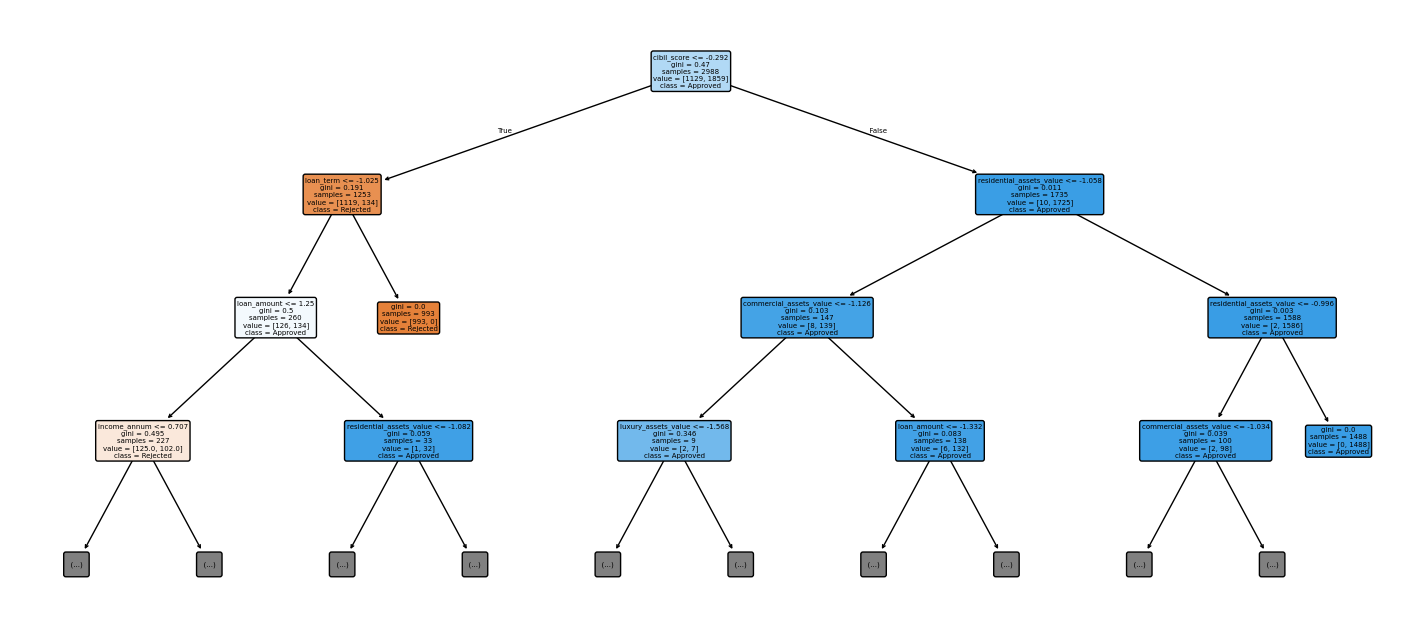

In [31]:
best_tree = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)

tree_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", best_tree)
])

tree_pipe.fit(X_train, y_train)


ohe = tree_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

feature_names = numerical_cols + list(cat_feature_names)


plt.figure(figsize=(18, 8))
plot_tree(
    tree_pipe.named_steps["model"],
    feature_names=feature_names,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    max_depth=3  
)
plt.show()

In [33]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def print_test_metrics(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    print(f"\n{title} (Test)")
    print("-" * (len(title) + 7))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")

log_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

log_param_grid = [
    {
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
        "model__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "model__penalty": ["l1"],
        "model__solver": ["liblinear"],
        "model__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "model__penalty": ["elasticnet"],
        "model__solver": ["saga"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.2, 0.5, 0.8]
    }
]

log_grid = GridSearchCV(
    estimator=log_pipe,
    param_grid=log_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

log_grid.fit(X_train, y_train)

print("\n Logistic Regression Best Params:")
print(log_grid.best_params_)
print(" Logistic Regression Best CV F1:", round(log_grid.best_score_, 4))

best_log = log_grid.best_estimator_
print_test_metrics(best_log, X_test, y_test, "Best Logistic Regression")

Fitting 5 folds for each of 22 candidates, totalling 110 fits

 Logistic Regression Best Params:
{'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
 Logistic Regression Best CV F1: 0.9522

Best Logistic Regression (Test)
-------------------------------
Accuracy : 0.9461
Precision: 0.9802
Recall   : 0.9322
F1 Score : 0.9556


c:\Users\abdel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\abdel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [34]:
from sklearn.tree import DecisionTreeClassifier

tree_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [None, 3, 5, 8, 12, 16],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8]
}

tree_grid = GridSearchCV(
    estimator=tree_pipe,
    param_grid=tree_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

tree_grid.fit(X_train, y_train)

print("\nDecision Tree Best Params:")
print(tree_grid.best_params_)
print(" Decision Tree Best CV F1:", round(tree_grid.best_score_, 4))

best_tree = tree_grid.best_estimator_
print_test_metrics(best_tree, X_test, y_test, "Best Decision Tree")

Fitting 5 folds for each of 192 candidates, totalling 960 fits

Decision Tree Best Params:
{'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 8, 'model__min_samples_split': 2}
 Decision Tree Best CV F1: 0.9812

Best Decision Tree (Test)
-------------------------
Accuracy : 0.9828
Precision: 0.9826
Recall   : 0.9900
F1 Score : 0.9862


In [36]:
import pandas as pd

tree_model = best_tree.named_steps["model"]

ohe = best_tree.named_steps["preprocess"].named_transformers_["cat"].named_steps["encoder"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

feature_names = numerical_cols + list(cat_feature_names)

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 Feature Importances:")
print(imp_df.head(15))


Top 15 Feature Importances:
                     feature  importance
4                cibil_score    0.846760
3                  loan_term    0.080789
2                loan_amount    0.028345
1               income_annum    0.024385
7        luxury_assets_value    0.010467
6    commercial_assets_value    0.002505
8           bank_asset_value    0.002369
0           no_of_dependents    0.002109
9    education_ Not Graduate    0.001516
5   residential_assets_value    0.000756
10        self_employed_ Yes    0.000000
